# Stock Prediction — ML Modeling
Random Forest · XGBoost · LSTM  |  Classification + Regression  |  Backtesting

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

from src.data.ingestion import load_config, get_market_data, compute_returns, train_test_split_timeseries
from src.features.engineering import build_feature_matrix, get_feature_columns
from src.models.random_forest import StockRandomForest
from src.models.xgboost_model import StockXGBoost
from src.models.lstm import StockLSTM
from src.evaluation.metrics import (
    classification_metrics, regression_metrics, directional_accuracy,
    backtest_strategy, strategy_summary, compare_models
)
from src.visualization.plots import (
    plot_feature_importance, plot_confusion_matrix,
    plot_equity_curves, plot_prediction_vs_actual
)

config = load_config('../config/config.yaml')
TICKER = 'AAPL'
%matplotlib inline

## 1. Prepare Data

In [2]:
df_raw = get_market_data(TICKER, config)
df_raw = compute_returns(df_raw)
df = build_feature_matrix(df_raw, config)

feature_cols = get_feature_columns(df)
print(f'Total samples : {len(df)}')
print(f'Features      : {len(feature_cols)}')
print(f'Target balance: {df["target_direction"].value_counts(normalize=True).to_dict()}')

Total samples : 1560
Features      : 45
Target balance: {1: 0.5378205128205128, 0: 0.4621794871794872}


In [3]:
train, val, test = train_test_split_timeseries(
    df, config['data']['test_split'], config['data']['val_split']
)
print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

X_train = train[feature_cols].values
y_train = train['target_direction'].values
X_val   = val[feature_cols].values
y_val   = val['target_direction'].values
X_test  = test[feature_cols].values
y_test  = test['target_direction'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train: 1092 | Val: 156 | Test: 312


## 2. Random Forest

In [4]:
rf = StockRandomForest(task='classification', **config['models']['random_forest'])
rf.fit(X_train_s, y_train)

rf_pred  = rf.predict(X_test_s)
rf_prob  = rf.predict_proba(X_test_s)
rf_metrics = classification_metrics(y_test, rf_pred, rf_prob)
print('Random Forest Test Metrics:')
for k, v in rf_metrics.items(): print(f'  {k}: {v:.4f}')

Random Forest Test Metrics:
  accuracy: 0.4423
  precision: 1.0000
  recall: 0.0114
  f1: 0.0225
  roc_auc: 0.4817


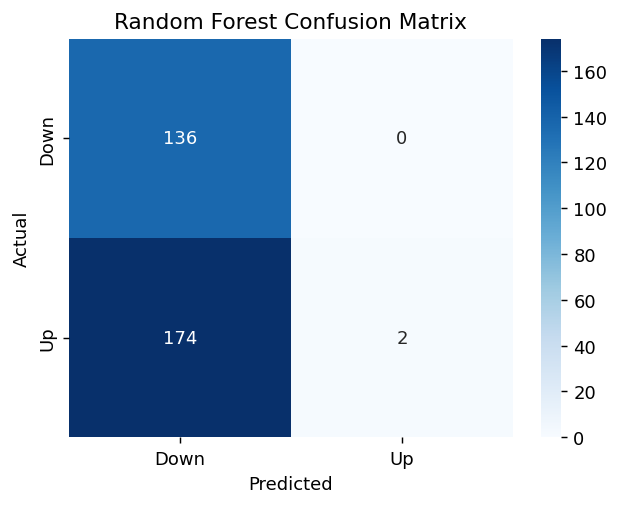

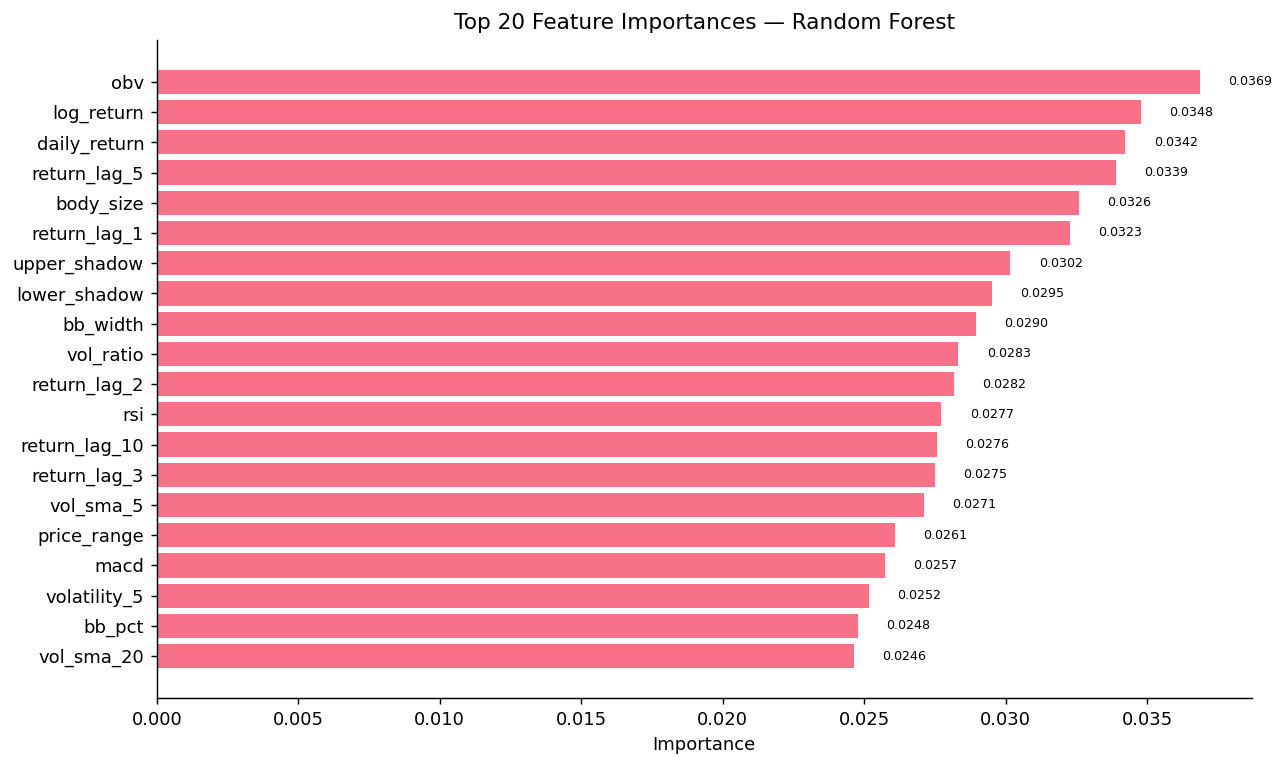

In [5]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, rf_pred)
fig = plot_confusion_matrix(cm_rf)
plt.title('Random Forest Confusion Matrix')
plt.show()

fi_rf = rf.feature_importance(feature_cols)
fig = plot_feature_importance(fi_rf, top_n=20, title='Random Forest')
plt.show()

## 3. XGBoost

In [6]:
xgb = StockXGBoost(task='classification', **config['models']['xgboost'])
xgb.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)])

xgb_pred   = xgb.predict(X_test_s)
xgb_prob   = xgb.predict_proba(X_test_s)
xgb_metrics = classification_metrics(y_test, xgb_pred, xgb_prob)
print('XGBoost Test Metrics:')
for k, v in xgb_metrics.items(): print(f'  {k}: {v:.4f}')

XGBoost Test Metrics:
  accuracy: 0.4071
  precision: 0.3333
  recall: 0.0511
  f1: 0.0887
  roc_auc: 0.4782


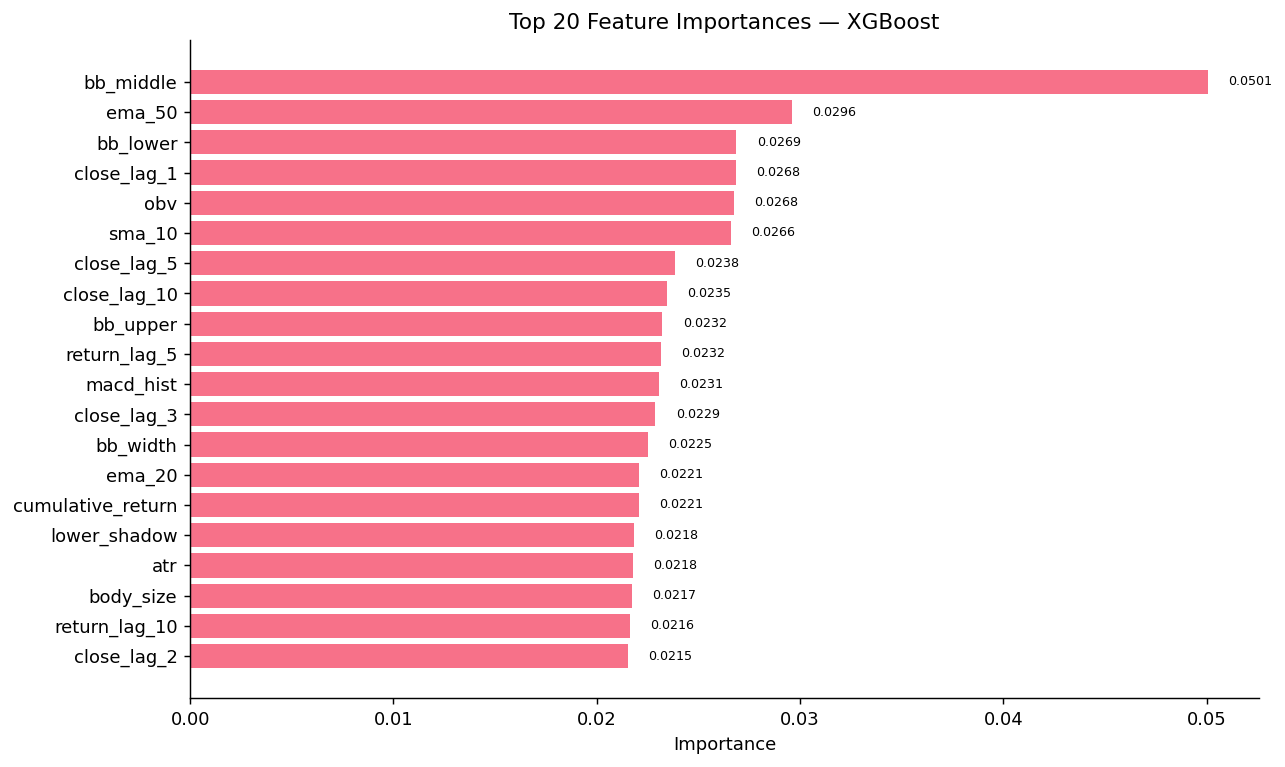

In [7]:
fi_xgb = xgb.feature_importance(feature_cols)
fig = plot_feature_importance(fi_xgb, top_n=20, title='XGBoost')
plt.show()

## 4. LSTM (Price Regression)

In [8]:
from src.models.lstm import _TF_AVAILABLE
if not _TF_AVAILABLE:
    print("TensorFlow not available on this Python version — skipping LSTM.")
    print("To enable LSTM: install Python <=3.12 and run: pip install tensorflow")
else:
    lstm_cfg = config['models']['lstm']
    lstm = StockLSTM(
        seq_len=lstm_cfg['sequence_length'],
        units=lstm_cfg['units'],
        dropout=lstm_cfg['dropout'],
        learning_rate=lstm_cfg['learning_rate'],
        task='regression',
    )
    lstm_features = [c for c in feature_cols if c in df.columns][:15]
    X_seq, y_seq, _ = lstm.prepare_data(df, lstm_features)
    split_train = int(len(X_seq) * 0.7)
    split_val   = int(len(X_seq) * 0.85)
    Xl_train, yl_train = X_seq[:split_train], y_seq[:split_train]
    Xl_val,   yl_val   = X_seq[split_train:split_val], y_seq[split_train:split_val]
    Xl_test,  yl_test  = X_seq[split_val:], y_seq[split_val:]
    lstm.fit(Xl_train, yl_train, Xl_val, yl_val,
             epochs=lstm_cfg['epochs'], batch_size=lstm_cfg['batch_size'])

TensorFlow not available on this Python version — skipping LSTM.
To enable LSTM: install Python <=3.12 and run: pip install tensorflow


In [9]:
if not _TF_AVAILABLE:
    print("Skipping LSTM evaluation — TensorFlow not installed.")
else:
    lstm_pred_scaled = lstm.predict(Xl_test)
    lstm_pred = lstm.inverse_transform_predictions(lstm_pred_scaled)
    lstm_actual = lstm.inverse_transform_predictions(yl_test)
    lstm_metrics = regression_metrics(lstm_actual, lstm_pred)
    lstm_dir_acc = directional_accuracy(np.diff(lstm_actual), np.diff(lstm_pred))
    print('LSTM Test Metrics (Regression):')
    for k, v in lstm_metrics.items(): print(f'  {k}: {v:.4f}')
    print(f'  directional_accuracy: {lstm_dir_acc:.4f}')
    test_dates = df.index[split_val + lstm_cfg['sequence_length']:]
    fig = plot_prediction_vs_actual(test_dates[:len(lstm_pred)], lstm_actual, lstm_pred,
                                     title='LSTM: Predicted vs Actual Price')
    plt.show()

Skipping LSTM evaluation — TensorFlow not installed.


## 5. Model Comparison

In [10]:
all_results = {
    'RandomForest': rf_metrics,
    'XGBoost'     : xgb_metrics,
}
compare_models(all_results)

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.4423,1.0000,0.0114,0.0225,0.4817
XGBoost,0.4071,0.3333,0.0511,0.0887,0.4782


## 6. Backtesting

=== Random Forest Backtest ===
  strategy_sharpe: 0.9866
  bah_sharpe: 1.6196
  strategy_max_dd: -0.0010
  bah_max_dd: -0.1661
  strategy_total_return: 0.0110
  bah_total_return: 0.4918
  n_trades: 4.0000

=== XGBoost Backtest ===
  strategy_sharpe: -2.4562
  bah_sharpe: 1.6196
  strategy_max_dd: -0.1171
  bah_max_dd: -0.1661
  strategy_total_return: -0.1171
  bah_total_return: 0.4918
  n_trades: 40.0000


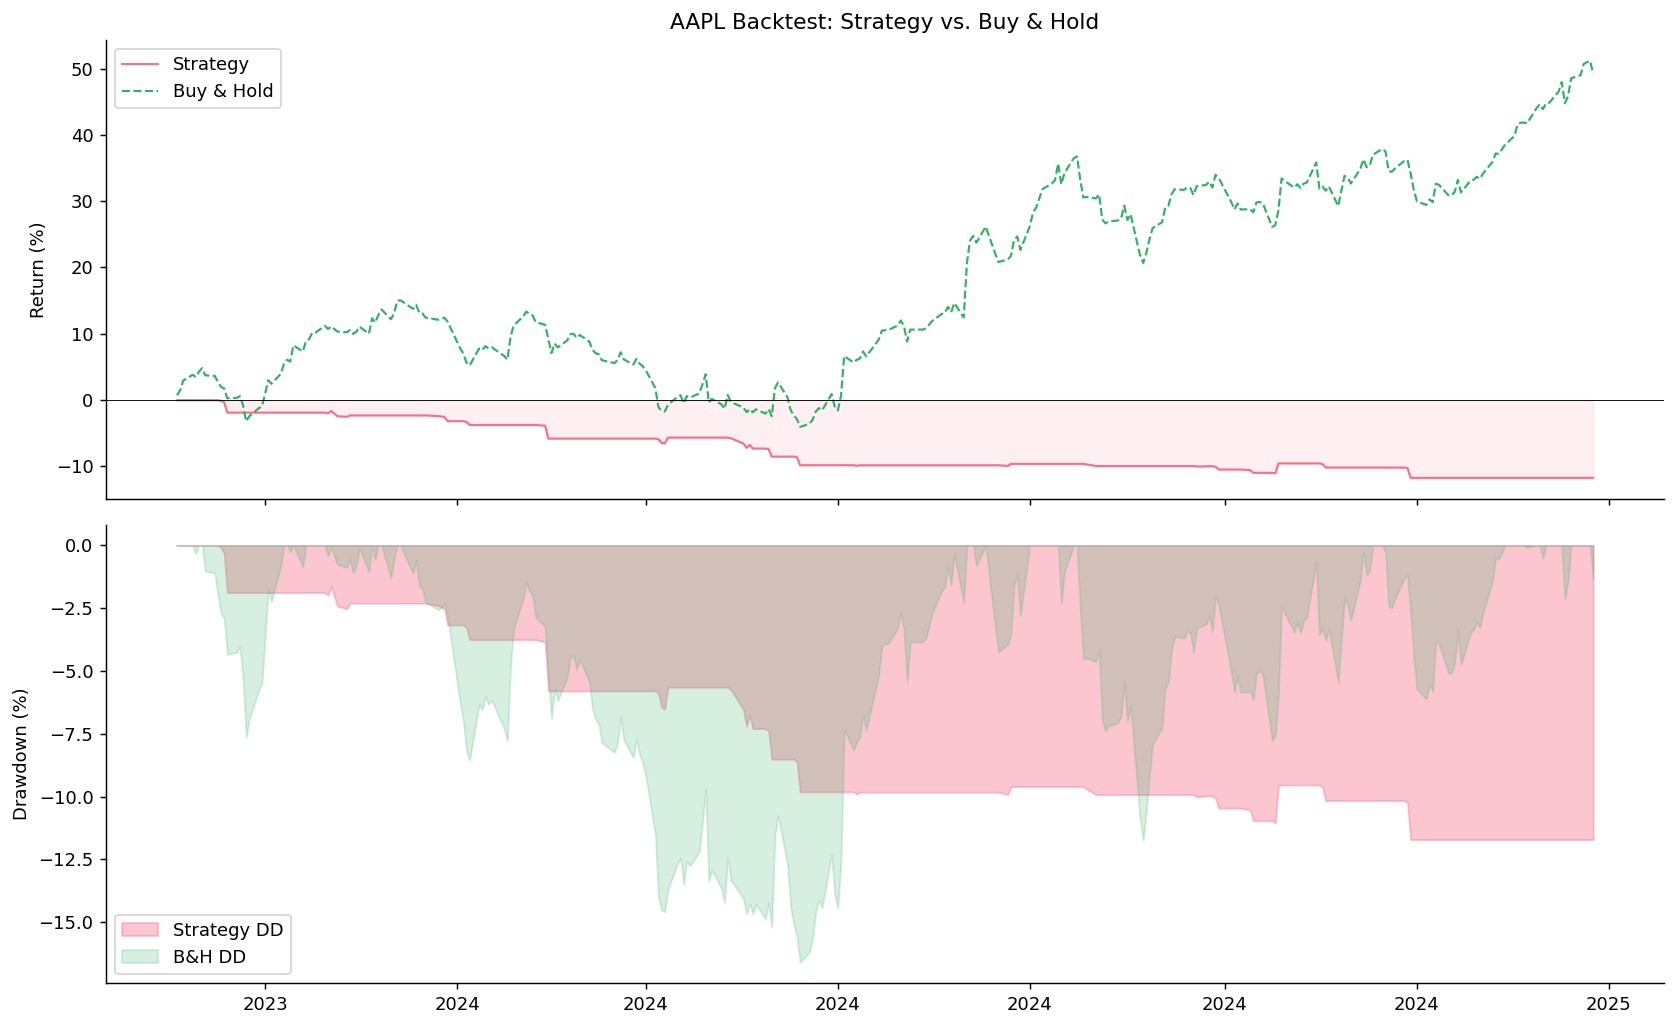

In [11]:
test_prices = test['close']

bt_rf  = backtest_strategy(test_prices, rf_pred)
bt_xgb = backtest_strategy(test_prices, xgb_pred)

print('=== Random Forest Backtest ===')
for k, v in strategy_summary(bt_rf).items(): print(f'  {k}: {v:.4f}')

print('\n=== XGBoost Backtest ===')
for k, v in strategy_summary(bt_xgb).items(): print(f'  {k}: {v:.4f}')

fig = plot_equity_curves(bt_xgb, ticker=TICKER)
plt.show()

## 7. Save Best Model

In [12]:
best = 'xgboost' if xgb_metrics['f1'] >= rf_metrics['f1'] else 'random_forest'
print(f'Best model: {best}')

xgb.save(f'../models_saved/{TICKER}_xgb.pkl')
rf.save(f'../models_saved/{TICKER}_rf.pkl')
print('Models saved.')

Best model: xgboost


Models saved.
